## Preparation

### Libraries import & metadata storage definitions

In [1]:
import os
import pandas as pd
import numpy as np
from scipy import stats
from crowdkit.aggregation import DawidSkene

import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\Элина\Desktop\Вузовские работы (магистратура)\1,2,3 CV,Осн.ML,NLP,Прак.ML\ML_homeworks_magistracy\.mlenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
contents_folder = "task_files_3"
checkpoint_dir = os.path.join(contents_folder, "checkpoints")
graph_dir = os.path.join(contents_folder, "graphs")
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

### Common functions

In [3]:
def bracket_comment(comment: str):
    return "(" + comment + ")" if comment else comment


def rates_histplot_all(rates: pd.DataFrame,
                       with_kde: bool = True,
                       n_bins: int = 10,
                       comment: str = ""):
    fig, ax = plt.subplots(figsize=(5, 3))

    sns.histplot(data=rates.to_numpy().flatten(), kde=with_kde, bins=n_bins)
    ax.set(
        title=f"Rates distribution over all pages {bracket_comment(comment)}",
        xlabel="Rate"
    )

    ax.grid(True, alpha=0.3, zorder=0)
    plt.show()    


def rates_histplot_pages(rates: pd.DataFrame,
                         with_kde: bool = True,
                         n_bins: int = 10,
                         comment: str = ""):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

    for i, column in enumerate(rates.columns):
        sns.histplot(
            data=rates, 
            x=column, 
            kde=with_kde, 
            ax=axes[i], 
            color=f'C{i}', 
            element="step", 
            bins=n_bins
        )
        axes[i].set(
            title=f"{column}",
            xlabel="Rate",
            xlim=(0,1)
        )
        if i:
            axes[i].set_ylabel("")
        axes[i].grid(True, alpha=0.3, zorder=0)

    plt.suptitle(f"Rates distribution over pages {bracket_comment(comment)}", fontsize=16)
    plt.tight_layout()
    plt.show()

### Manual assessment analysis

In [56]:
man_rates_path = os.path.join(contents_folder, "requests_orig_rate.csv")
n_pages = 5
man_rates = pd.read_csv(man_rates_path, names=[f"Page_{i+1}" for i in range(n_pages)])
man_rates

,Page_1,Page_2,Page_3,Page_4,Page_5
0,1.00,0.10,0.60,0.85,0.70
1,0.13,0.10,0.20,0.10,0.00
2,0.30,0.30,0.00,0.15,0.00
3,0.20,0.93,0.90,0.93,0.90
4,0.95,0.30,0.12,0.10,0.10
5,0.85,0.00,0.30,0.65,0.35
6,0.55,0.85,0.55,0.37,0.10
7,1.00,0.50,0.50,0.50,0.50
8,0.95,0.30,0.90,0.87,0.97
9,0.90,0.70,0.70,1.00,0.80


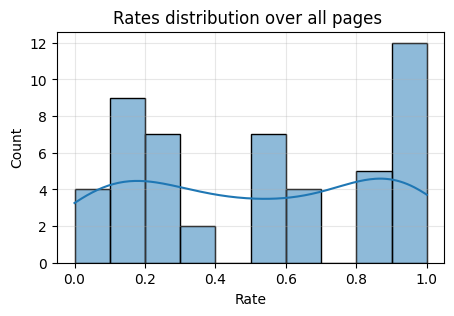

In [5]:
rates_histplot_all(man_rates)

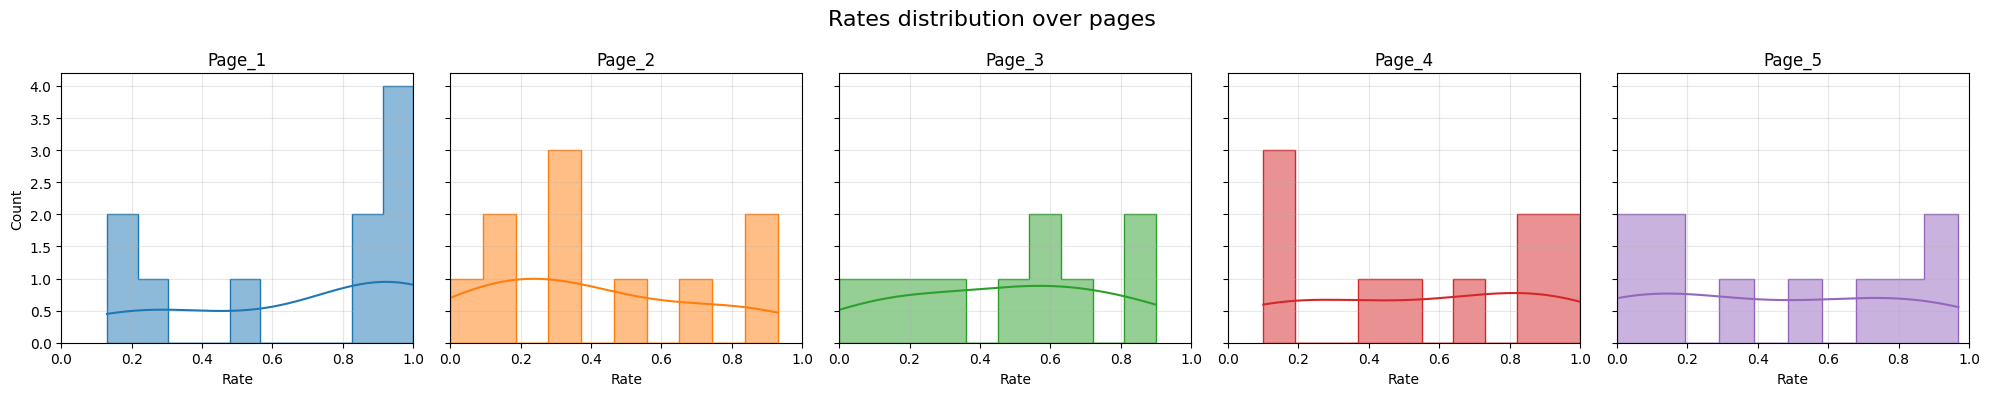

In [57]:
rates_histplot_pages(man_rates)

In [58]:
metrics_unif = {
    "stats": [],
    "pvalues": []
}
metrics_norm = {
    "stats": [],
    "pvalues": []
}
metrics_beta = {
    "stats": [],
    "pvalues": []
}

for i in range(n_pages):
    page_rates = man_rates[f"Page_{i+1}"]
    
    stat_unif, pvalue_unif = stats.kstest(page_rates, 'uniform', args=(0, 1))
    stat_norm, pvalue_norm = stats.kstest(page_rates, 'norm', args=(0, 1))
    stat_beta, pvalue_beta = stats.kstest(page_rates, 'beta', args=(1, 0.2))

    metrics_unif["stats"].append(stat_unif)
    metrics_unif["pvalues"].append(pvalue_unif)
    metrics_norm["stats"].append(stat_norm)
    metrics_norm["pvalues"].append(pvalue_norm)
    metrics_beta["stats"].append(stat_beta)
    metrics_beta["pvalues"].append(pvalue_beta)

In [ ]:
def print_distr_conclusion(pvalues: list,
                           distr_name: str,
                           sign_level: float = 0.05):
    print("")
    for i in range(len(pvalues)):
        conclusion = "" if pvalues[i] >= sign_level else "non-"
        print(f"   page {i+1} uniform p-value = {pvalues[i]:.4f}  =>  "
              f"rates are {conclusion}{distr_name} distributed")

In [59]:
sign_level = 0.05
print(f"With chosen significance level {sign_level}:")
print_distr_conclusion(metrics_unif["pvalues"], "uniformly", sign_level)
print_distr_conclusion(metrics_norm["pvalues"], "normally", sign_level)
print_distr_conclusion(metrics_beta["pvalues"], "beta", sign_level)

With chosen significance level 0.05:

   page 1 uniform p-value = 0.0229  =>  rates are non-uniformly distributed
   page 2 uniform p-value = 0.2705  =>  rates are uniformly distributed
   page 3 uniform p-value = 0.9996  =>  rates are uniformly distributed
   page 4 uniform p-value = 0.4841  =>  rates are uniformly distributed
   page 5 uniform p-value = 0.2705  =>  rates are uniformly distributed

   page 1 uniform p-value = 0.0022  =>  rates are non-normally distributed
   page 2 uniform p-value = 0.0078  =>  rates are non-normally distributed
   page 3 uniform p-value = 0.0078  =>  rates are non-normally distributed
   page 4 uniform p-value = 0.0030  =>  rates are non-normally distributed
   page 5 uniform p-value = 0.0078  =>  rates are non-normally distributed

   page 1 uniform p-value = 0.1354  =>  rates are beta distributed
   page 2 uniform p-value = 0.0008  =>  rates are non-beta distributed
   page 3 uniform p-value = 0.0002  =>  rates are non-beta distributed
   page 4 un

The rates for pages:
- 1 can be considered distributed as $\beta(1, 0.2)$,  
- 2-5 can be considered standart uniformly distributed,

so the following "assessors" rates will be sampled from $\beta(1, 0.2)$ and $\mathcal{U}[0; 1]$. 

## Assessors rating modelling

### Main constants & functions

In [60]:
n_pages = 5
n_good_assessors = 8500
n_weak_assessors = 1000
n_frauders = 500

In [ ]:
def generate_good_rates(n_pages: int,
                        n_assessors: int):
    rates_dict = {}

    rates_dict["Page_1"] = np.random.beta(1, 0.2, size=n_assessors)

    for i in range(1, n_pages):
        column_name = f"Page_{i+1}"
        rates_dict[column_name] = np.random.uniform(
            low=1-(i-1)/n_pages if i else 1-i/n_pages, 
            high=1-(i+1)/n_pages, 
            size=n_assessors // 5
        )
        rates_dict[column_name] = np.concat((
            rates_dict[column_name], 
            np.random.uniform(0, 1, size=(n_assessors // 5 * 4))
        ))

    return np.clip(pd.DataFrame(rates_dict).astype(float), 0, 1)


def generate_rates(n_pages: int,
                   n_assessors: int,
                   distribution,
                   *args):
    rates_dict = {}
    for i in range(n_pages):
        column_name = f"Page_{i+1}"
        rates_dict[column_name] = distribution(size=n_assessors, *args)

    return np.clip(pd.DataFrame(rates_dict).astype(float), 0, 1)

### Rates dataset creation

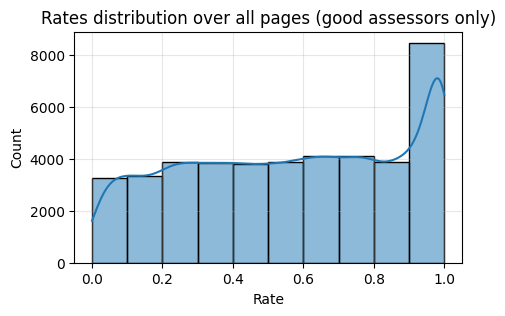

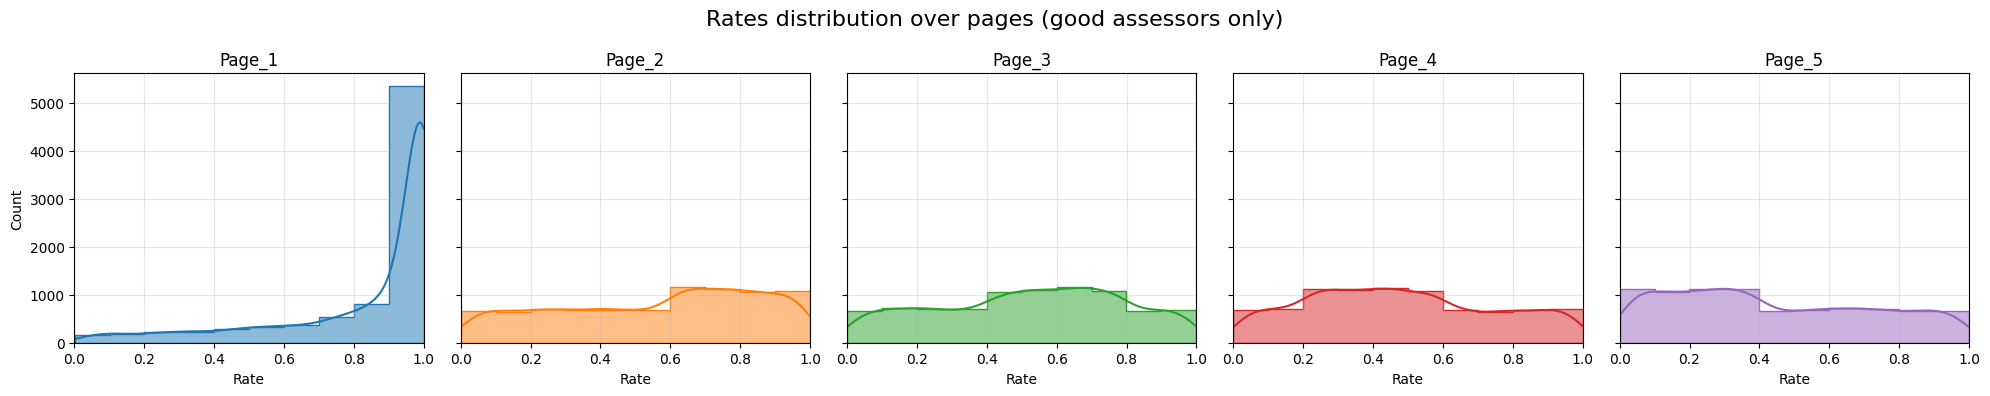

In [81]:
np.random.seed(42)

rates = generate_good_rates(n_pages, n_good_assessors)

comment_good = "good assessors only"
rates_histplot_all(rates, comment=comment_good)
rates_histplot_pages(rates, comment=comment_good)

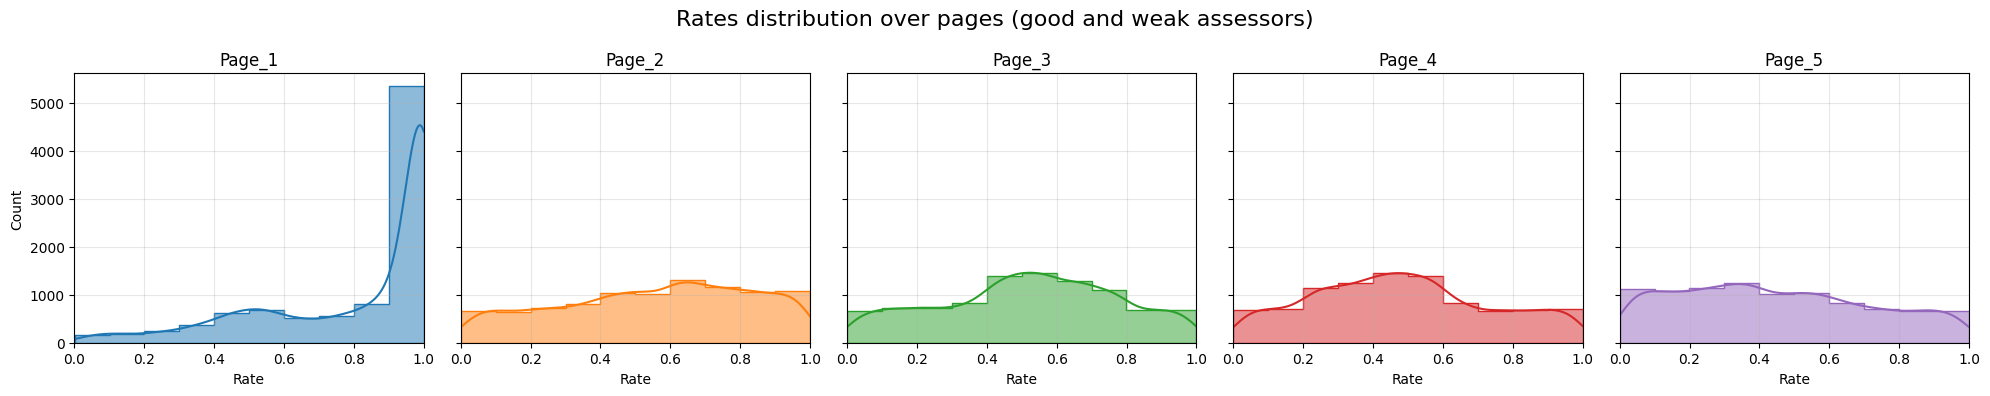

In [82]:
np.random.seed(42)

rates = pd.concat((rates, 
                   generate_rates(n_pages, n_weak_assessors, np.random.normal, 0.5, 0.1)))
comment_weak = "good and weak assessors"
rates_histplot_pages(rates, comment=comment_weak)

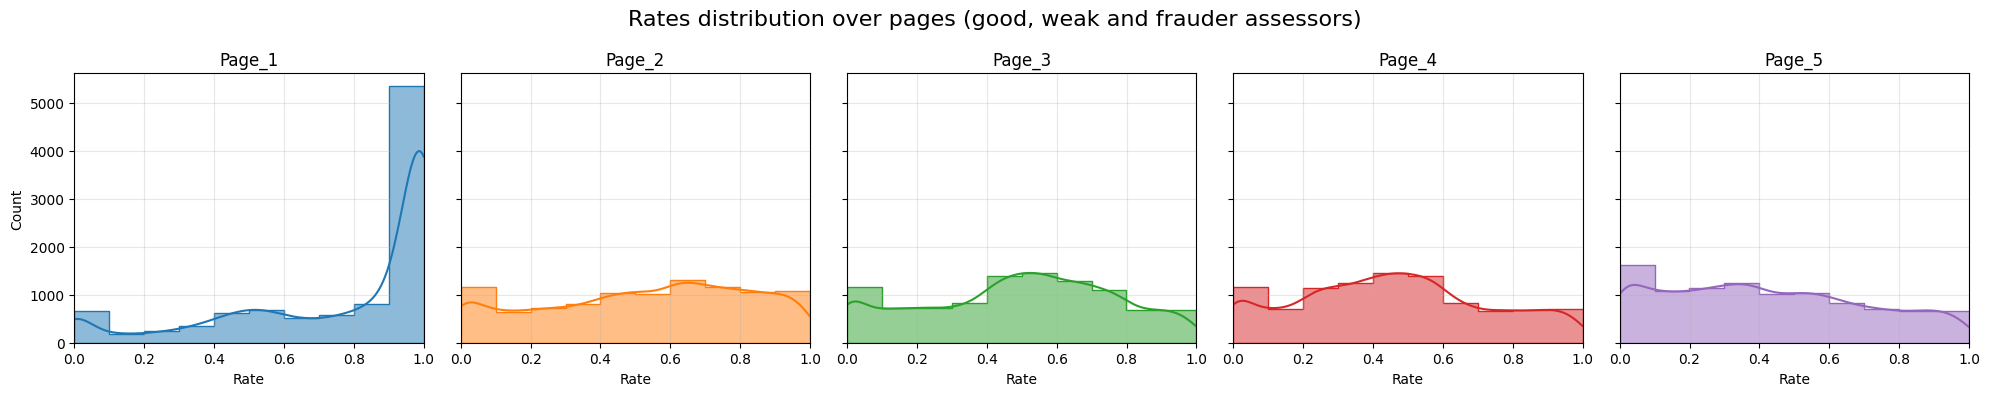

In [83]:
np.random.seed(42)

rates = pd.concat((rates, 
                   generate_rates(n_pages, n_frauders, np.random.randint, 0, 1)))
comment_all = "good, weak and frauder assessors"
rates_histplot_pages(rates, comment=comment_all)

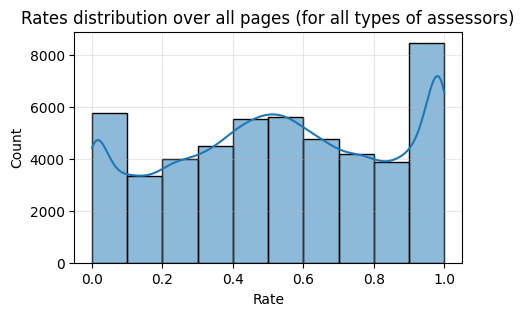

In [85]:
np.random.seed(42)

rates = rates.sample(frac=1).reset_index(drop=True)
rates_histplot_all(rates, comment="for all types of assessors")

In [93]:
rates.describe()

,Page_1,Page_2,Page_3,Page_4,Page_5
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.759521,0.525292,0.491541,0.456697,0.423514
std,0.306552,0.292552,0.272290,0.269441,0.285174
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.557247,0.294348,0.286184,0.254184,0.182936
50%,0.929449,0.557576,0.512946,0.451895,0.394222
75%,0.997813,0.766479,0.695808,0.641808,0.640830
max,1.000000,0.999981,0.999789,0.999972,0.999841


## Dawid-Skene implementation

### Data preparation

In [166]:
def discretize_rates(rates: pd.DataFrame,
                     n_bins: int = 10):
    rates_discrete = rates.copy()
    for column in rates_discrete.columns:
        rates_discrete[column] = pd.cut(
            rates_discrete[column], 
            bins=n_bins, 
            right=True, 
            include_lowest=True,
            labels=range(n_bins)
        ).astype(int)
    return rates_discrete

In [168]:
rates_discrete = discretize_rates(rates, n_bins=10)
rates_discrete.head(4)

,Page_1,Page_2,Page_3,Page_4,Page_5
0,9,8,4,1,9
1,9,2,7,2,2
2,9,3,3,7,3
3,7,0,7,1,8


In [148]:
rates.head(4)

,Page_1,Page_2,Page_3,Page_4,Page_5
0,0.988184,0.841595,0.459505,0.178437,0.969826
1,0.958503,0.217893,0.724122,0.204971,0.247316
2,0.984527,0.393610,0.314818,0.774993,0.314202
3,0.797528,0.074005,0.716201,0.109105,0.844260


In [169]:
rates_longed_list = []
for assess_id, assess_rates in rates_discrete.iterrows():
    for page_id, page_name in enumerate(rates_discrete.columns):
        rates_longed_list.append({
            "worker": assess_id,
            "task":   page_id,
            "label":  assess_rates[page_name]
        })

rates_longed = pd.DataFrame(rates_longed_list)

In [174]:
rates_longed.head(10)

,worker,task,label
0,0,0,9
1,0,1,8
2,0,2,4
3,0,3,1
4,0,4,9
5,1,0,9
6,1,1,2
7,1,2,7
8,1,3,2
9,1,4,2


### Implementation

In [175]:
dawid_skene = DawidSkene(n_iter=100)
predictions = dawid_skene.fit_predict(rates_longed)

aggregated_labels = dawid_skene.probas_.idxmax(axis=1)
assessor_errors = dawid_skene.errors_

In [176]:
print("Most likely rate classes for pages:")
aggregated_labels

Most likely rate classes for pages:


task
0    9
1    7
2    6
3    2
4    1
dtype: int64

In [158]:
print(f"Error matrices for assessors 0-2:")
assessor_errors.loc[:2].sort_index()

Error matrices for assessors 0-2:


0             1         2             3             4
worker label                                                                  
0      0      1.000000e-10  1.000000e+00  0.333333  5.000000e-11  1.000000e-10
       2      1.000000e-10  1.000000e-10  0.333333  5.000000e-01  1.000000e-10
       4      1.000000e+00  1.000000e-10  0.333333  5.000000e-01  1.000000e+00
1      1      1.000000e+00  1.000000e+00  0.333333  5.000000e-01  1.000000e-10
       3      1.000000e-10  1.000000e-10  0.333333  5.000000e-01  1.000000e-10
       4      1.000000e-10  1.000000e-10  0.333333  5.000000e-11  1.000000e+00
2      1      1.000000e+00  1.000000e-10  0.333333  1.000000e+00  1.000000e-10
       3      1.000000e-10  1.000000e+00  0.333333  5.000000e-11  1.000000e-10
       4      1.000000e-10  1.000000e-10  0.333333  5.000000e-11  1.000000e+00

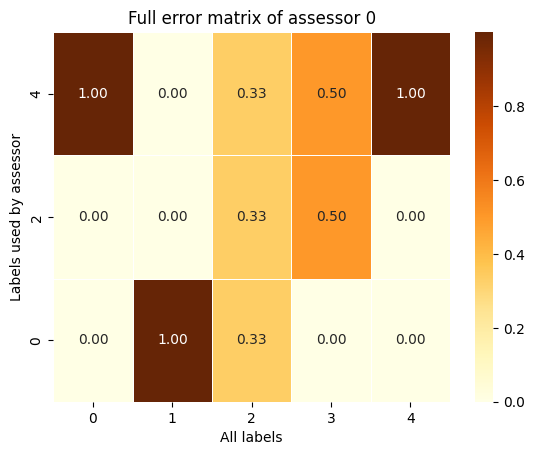

In [159]:
example_assess_id = 0

ax = sns.heatmap(
    assessor_errors.loc[example_assess_id].sort_index(ascending=False),
    annot=True, fmt=".2f",
    linewidth=.5,
    cmap="YlOrBr"
)
ax = ax.set(
    title=f"Full error matrix of assessor {example_assess_id}",
    xlabel="All labels",
    ylabel="Labels used by assessor"
)

In [201]:
assess_accs_vanilla = []
for assess_id in rates_discrete.index:
    assessor_data = rates_longed[rates_longed['worker'] == assess_id]
    
    true_labels = aggregated_labels[assessor_data['task']].values
    assessor_labels = assessor_data['label'].values
    
    accuracy = (true_labels == assessor_labels).mean()
    assess_accs_vanilla.append(accuracy)

assess_accs_from_errors = []
for assess_id in rates_discrete.index:
    assessor_error_matrix = assessor_errors.loc[assess_id]
    accuracy = np.diag(assessor_error_matrix).mean()
    assess_accs_from_errors.append(accuracy)

In [253]:
print(f"Accuracies of example assessor ({example_assess_id}):")
print("- vanilla:    ", assess_accs_vanilla[example_assess_id])
print("- from errors:", assess_accs_from_errors[example_assess_id])

Accuracies of example assessor (0):
- vanilla:     0.2
- from errors: 0.12500000005


In [205]:
assess_accs = []
for acc in assess_accs_vanilla:
    assess_accs.append({
        "accuracy": acc, 
        "type": "vanilla"
    })
for acc in assess_accs_from_errors:
    assess_accs.append({
        "accuracy": acc, 
        "type": "from_errors"
    })
assess_accs = pd.DataFrame(assess_accs)

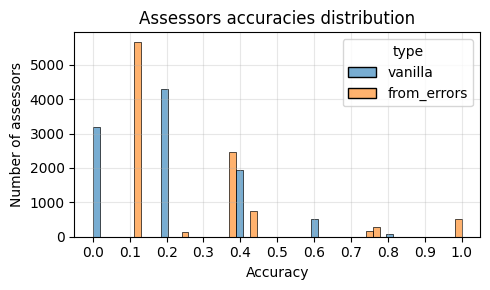

In [216]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.histplot(
    assess_accs, 
    x="accuracy",
    hue="type",
    ax=ax,
    alpha=0.6
)

ax.set(
    title=f"Assessors accuracies distribution",
    xlabel="Accuracy",
    xticks=[i*0.1 for i in range(11)],
    ylabel="Number of assessors"
)
ax.grid(True, alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

### Resulting assessors accuracy analysis

#### Vanilla accuracy

In [230]:
assess_accs_vanilla = np.array(assess_accs_vanilla)

In [242]:
acc_lower_limit = assess_accs_vanilla.min()
worst_rates = rates.loc[assess_accs_vanilla <= acc_lower_limit]

print(f"The assessors with accuracy <={acc_lower_limit} found: {worst_rates.shape[0]} of original " 
      f"{n_weak_assessors + n_frauders} ({n_weak_assessors} weak assessors and {n_frauders} frauders)")

print("The worst assessors examples:")
worst_rates.head(15)

The assessors with accuracy <=0.0 found: 3179 of original 1500 (1000 weak assessors and 500 frauders)
The worst assessors examples:


,Page_1,Page_2,Page_3,Page_4,Page_5
3,0.797528,0.074005,0.716201,0.109105,0.844260
5,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000
13,0.333848,0.323156,0.407362,0.685770,0.594521
17,0.567088,0.154373,0.989023,0.553621,0.695571
19,0.866781,0.963459,0.056629,0.133031,0.313541
23,0.217725,0.223054,0.579793,0.397054,0.241064
25,0.771133,0.937262,0.872054,0.744867,0.309622


In [243]:
print(f"Among {worst_rates.shape[0]} worst assessors there are "
      f"{worst_rates[(worst_rates == acc_lower_limit).all(axis=1)].shape[0]} frauders "
      f"of original {n_frauders}")

Among 3179 worst assessors there are 500 frauders of original 500


In [244]:
acc_upper_limit = 0.6
best_rates = rates.loc[np.where(assess_accs_vanilla >= acc_upper_limit)]

print(f"The assessors with accuracy found: {best_rates.shape[0]} of original {n_good_assessors}")

print("The best assessors examples:")
best_rates.head(15)

The assessors with accuracy found: 583 of original 8500
The best assessors examples:


,Page_1,Page_2,Page_3,Page_4,Page_5
41,0.999999,0.224154,0.694724,0.251093,0.931321
42,0.980953,0.770772,0.639536,0.391235,0.016248
67,0.999122,0.681133,0.555346,0.203035,0.138756
75,0.979248,0.774107,0.110030,0.787160,0.101296
99,0.999050,0.243355,0.652273,0.282041,0.764755
100,0.997156,0.744063,0.667584,0.207737,0.127877
110,0.305836,0.534090,0.619300,0.277369,0.107045
189,0.988443,0.682425,0.691266,0.235756,0.248007
204,0.999314,0.497001,0.620652,0.731802,0.164783
216,0.999442,0.747325,0.042435,0.223517,0.948087


#### Accuracy calculated from `dawid_skene.errors_`

In [245]:
assess_accs_from_errors = np.array(assess_accs_from_errors)

In [246]:
acc_lower_limit = assess_accs_from_errors.min()
worst_rates = rates.loc[assess_accs_from_errors <= acc_lower_limit]

print(f"The assessors with accuracy <={acc_lower_limit:.4f} found: {worst_rates.shape[0]} of original " 
      f"{n_weak_assessors + n_frauders} ({n_weak_assessors} weak assessors and {n_frauders} frauders)")

print("The worst assessors examples:")
worst_rates.head(15)

The assessors with accuracy <=0.1111 found: 906 of original 1500 (1000 weak assessors and 500 frauders)
The worst assessors examples:


,Page_1,Page_2,Page_3,Page_4,Page_5
21,0.999999,0.730079,0.882207,0.911226,0.968286
22,0.914785,0.698736,0.973102,0.944496,0.165642
41,0.999999,0.224154,0.694724,0.251093,0.931321
59,0.997257,0.778542,0.726177,0.968625,0.064679
61,0.818543,0.027317,0.569563,0.028828,0.532313
74,0.413872,0.518455,0.644363,0.446468,0.454136
75,0.979248,0.774107,0.110030,0.787160,0.101296
76,0.515030,0.519050,0.588523,0.730792,0.618426
123,0.362068,0.469197,0.291297,0.390263,0.375546
139,0.724850,0.644556,0.567171,0.678201,0.571157


In [249]:
print(f"Among {worst_rates.shape[0]} worst assessors there are "
      f"{worst_rates[(worst_rates == acc_lower_limit).all(axis=1)].shape[0]} frauders "
      f"of original {n_frauders}")

Among 906 worst assessors there are 0 frauders of original 500


In [252]:
acc_upper_limit = 0.6
best_rates = rates.loc[np.where(assess_accs_from_errors >= acc_upper_limit)]

print(f"The assessors with accuracy found: {best_rates.shape[0]} of original {n_good_assessors}")

print("The best assessors examples:")
best_rates.head(15)

The assessors with accuracy found: 966 of original 8500
The best assessors examples:


,Page_1,Page_2,Page_3,Page_4,Page_5
2,0.984527,0.393610,0.314818,0.774993,0.314202
5,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000
34,0.000000,0.000000,0.000000,0.000000,0.000000
36,0.991898,0.844317,0.002632,0.059177,0.895694
39,0.397561,0.407933,0.392895,0.617276,0.470824
44,0.478033,0.465135,0.500053,0.620053,0.563366
49,0.999549,0.349585,0.964786,0.486791,0.394820
